# Delay Characterization: Cross-Correlation & Mutual Information (Industrial Data)

**Objective:** Identify time lag between two sensor signals from industrial/experimental data using:
1. **Cross-correlation** (using `scipy.signal.correlate` + `scipy.signal.correlation_lags`)
2. **Mutual Information** (histogram-based estimator)

Uses `ParquetDataSource` to load data from Parquet files.

In [1]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import correlate, correlation_lags

from synch_analysis import (
    ParquetDataSource,
)

In [2]:
# Publication-quality figure settings
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.size': 4,
    'ytick.major.width': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'lines.markersize': 4
})

## Configuration

Set the Parquet file path, column names, and time window for analysis.

In [3]:
# --- DATA SOURCE SETUP (VarA/VarB) ---
parquet = ParquetDataSource(
    file_path="../data/datos_ind.pqt",
    column_a="VarA",
    column_b="VarB",
    index_start="2021-11-03 23:00:00",
    index_end="2021-11-03 23:25:00",
    window=1,             # Rolling mean window
    lag=None,              # No initial lag
    sampling_rate=1.0,     # 1 Hz
)

signal_pair = parquet.load()
s1 = signal_pair.signal_b
s2 = signal_pair.signal_a
sr = signal_pair.sampling_rate

print(f'Signal A: {signal_pair.name_a} ({len(s1)} samples)')
print(f'Signal B: {signal_pair.name_b} ({len(s2)} samples)')
print(f'Sampling rate: {sr} Hz')

Signal A: VarA (1515 samples)
Signal B: VarB (1515 samples)
Sampling rate: 1.0 Hz


## 1. Cross-Correlation Method

In [4]:
# --- CROSS-CORRELATION ---

# Normalize signals
s1_norm = (s1 - np.mean(s1)) / np.std(s1)
s2_norm = (s2 - np.mean(s2)) / np.std(s2)

# Compute cross-correlation
max_lag = min(600, len(s1) // 4)  # Up to 10 min or 1/4 signal length
corr = correlate(s1_norm, s2_norm, mode='full')
lags = correlation_lags(len(s1_norm), len(s2_norm), mode='full')

# Restrict to max_lag range
mask = (lags >= -max_lag) & (lags <= max_lag)
lags = lags[mask]
corr = corr[mask]

# Find peak
peak_idx = np.argmax(corr)
cc_lag = lags[peak_idx]
cc_max = corr[peak_idx]
cc_lag_sec = cc_lag / sr

print(f'Cross-correlation peak at lag: {cc_lag} steps ({cc_lag_sec:.1f}s)')
print(f'Max correlation: {cc_max:.4f}')

Cross-correlation peak at lag: 83 steps (83.0s)
Max correlation: 807.2435


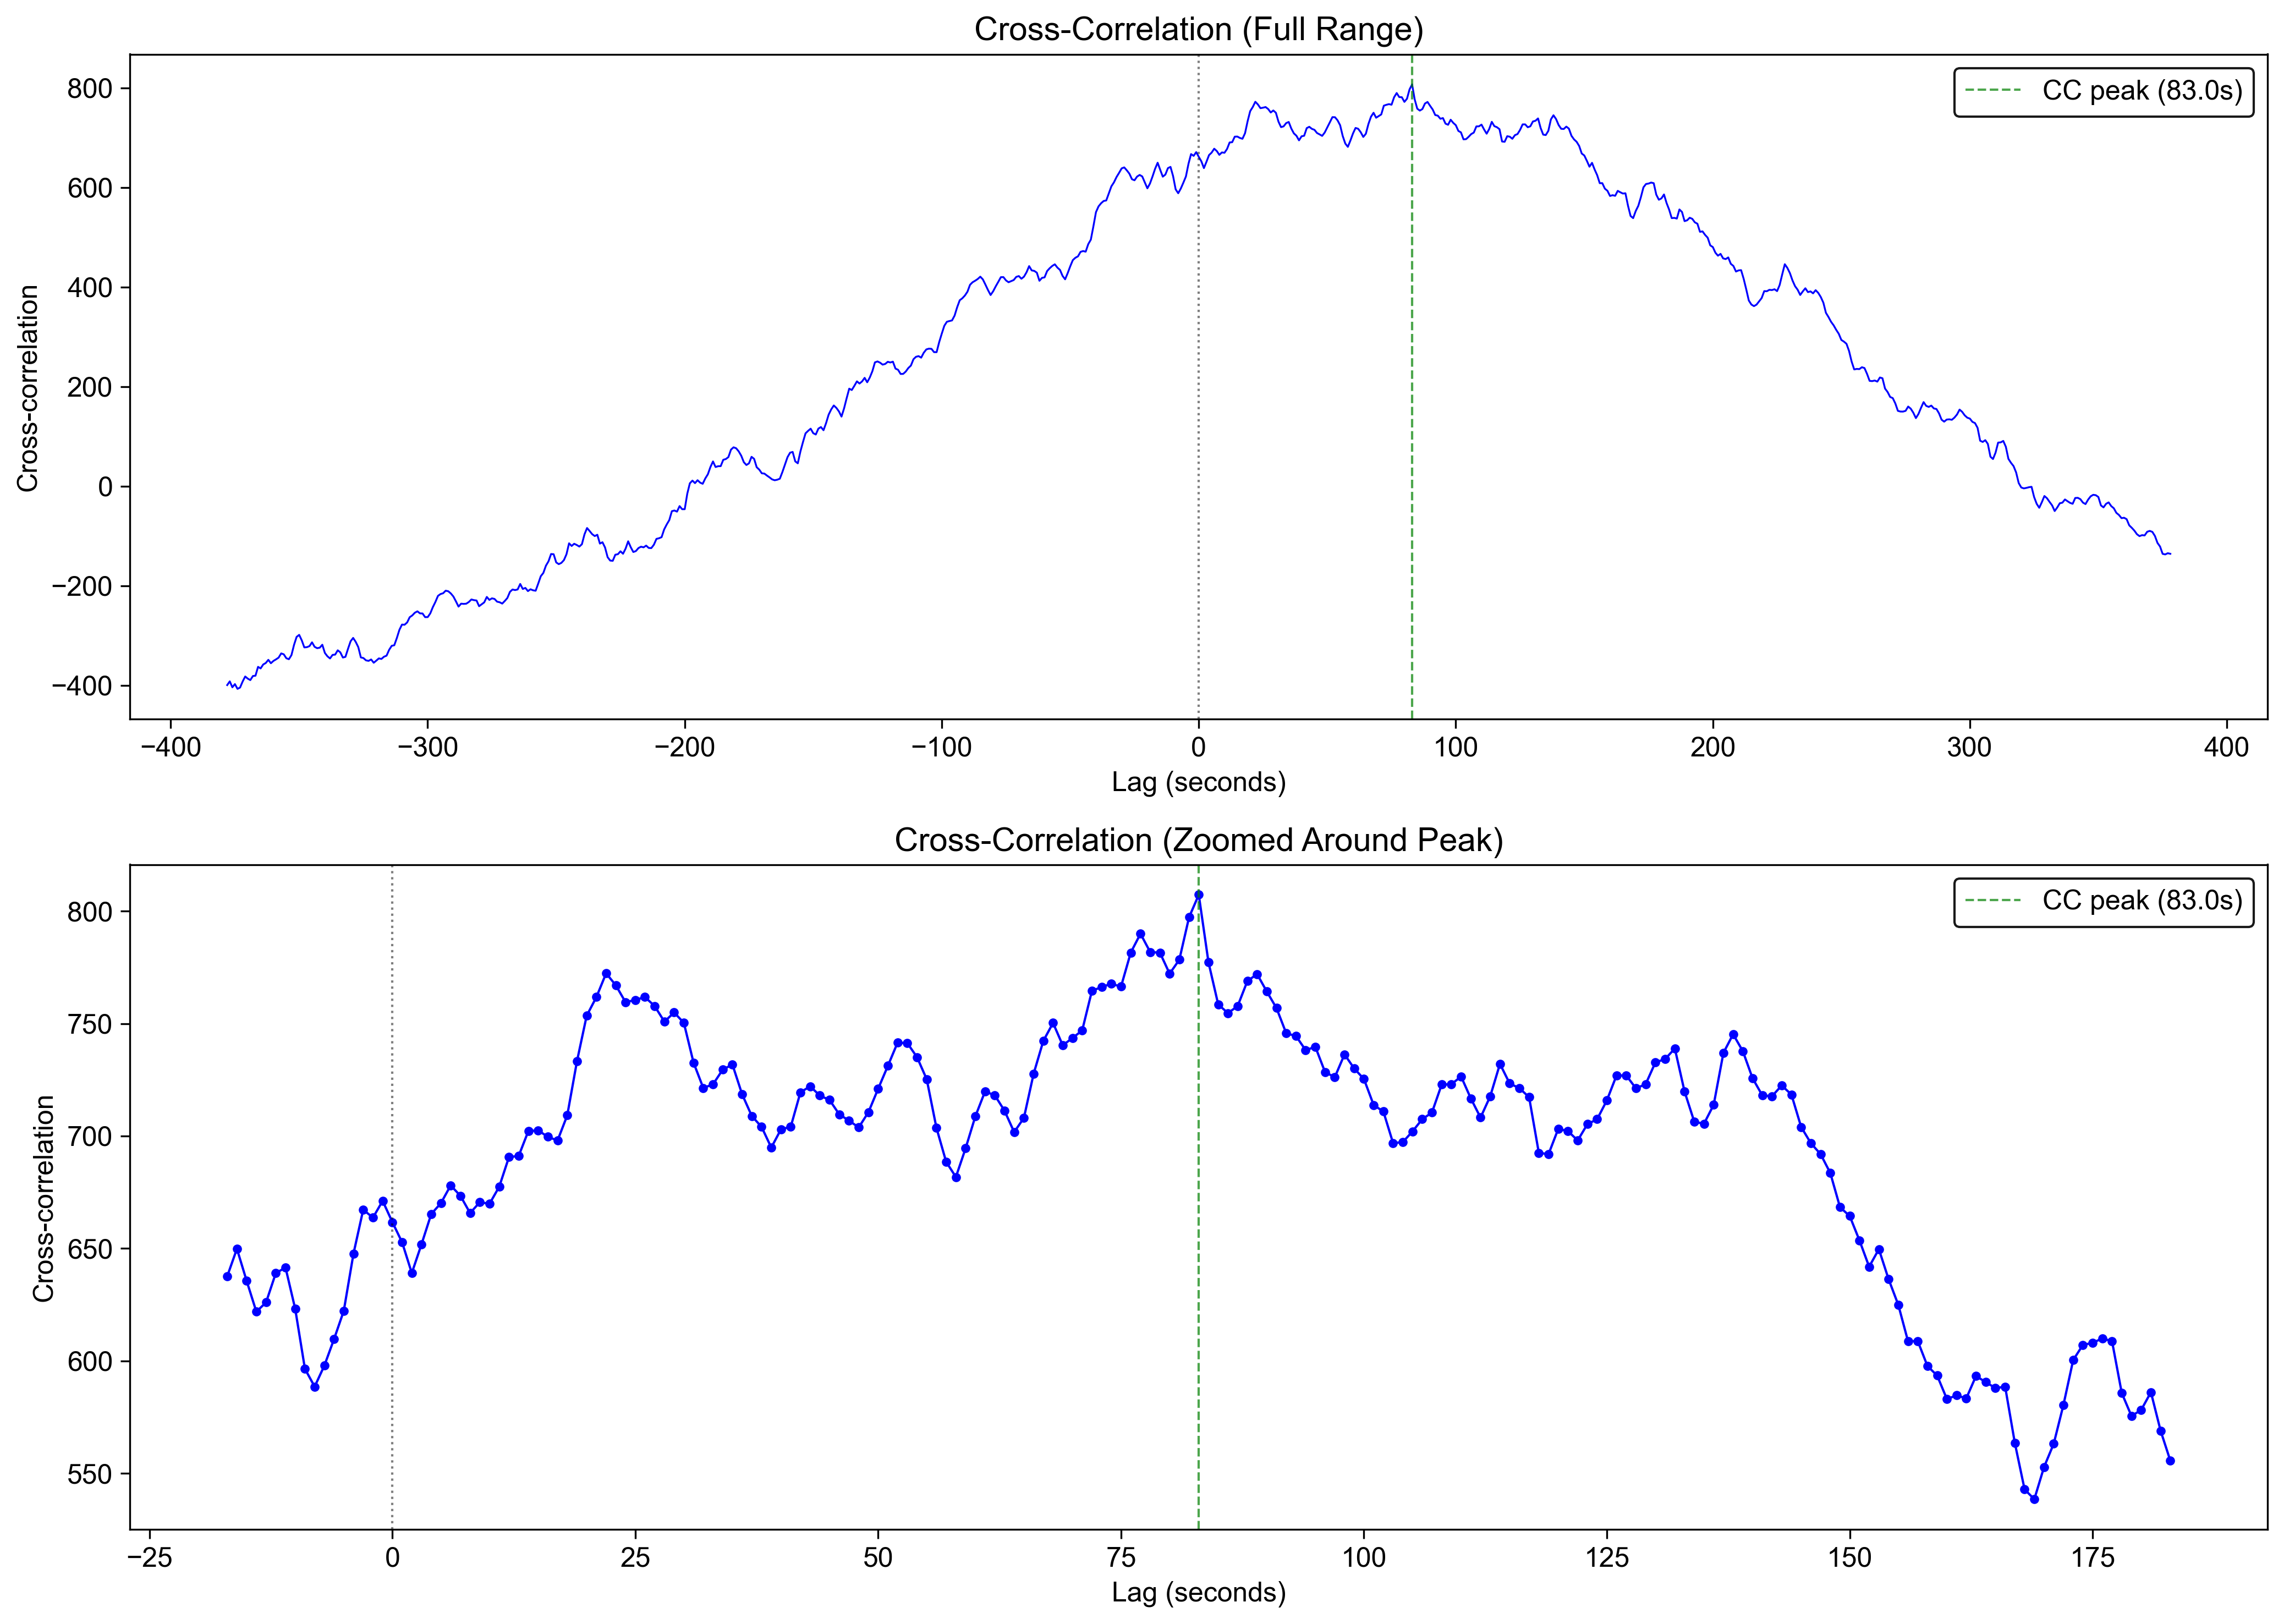

In [5]:
# Plot cross-correlation
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0].plot(lags / sr, corr, 'b-', linewidth=0.8)
axes[0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0].axvline(x=cc_lag_sec, color='g', linestyle='--', alpha=0.7, label=f'CC peak ({cc_lag_sec:.1f}s)')
axes[0].set_xlabel('Lag (seconds)')
axes[0].set_ylabel('Cross-correlation')
axes[0].set_title('Cross-Correlation (Full Range)')
axes[0].legend(frameon=True, framealpha=0.9, edgecolor='black')

zoom_range = 100
mask = (lags >= cc_lag - zoom_range) & (lags <= cc_lag + zoom_range)
axes[1].plot(lags[mask] / sr, corr[mask], 'b-o', linewidth=1, markersize=3)
axes[1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1].axvline(x=cc_lag_sec, color='g', linestyle='--', alpha=0.7, label=f'CC peak ({cc_lag_sec:.1f}s)')
axes[1].set_xlabel('Lag (seconds)')
axes[1].set_ylabel('Cross-correlation')
axes[1].set_title('Cross-Correlation (Zoomed Around Peak)')
axes[1].legend(frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

## 2. Mutual Information Method

In [6]:
# --- MUTUAL INFORMATION ---

def mutual_info_lag(s1, s2, max_lag, bins=30):
    """Compute mutual information for different lags."""
    mi_values = []
    mi_lags = np.arange(-max_lag, max_lag + 1)
    
    for lag in mi_lags:
        if lag > 0:
            s1_shifted = s1[lag:]
            s2_shifted = s2[:-lag]
        elif lag < 0:
            s1_shifted = s1[:lag]
            s2_shifted = s2[-lag:]
        else:
            s1_shifted = s1
            s2_shifted = s2
        
        hist_2d, _, _ = np.histogram2d(s1_shifted, s2_shifted, bins=bins)
        hist_1 = np.sum(hist_2d, axis=1)
        hist_2 = np.sum(hist_2d, axis=0)
        
        mi = 0.0
        total = np.sum(hist_2d)
        if total > 0:
            pxy = hist_2d / total
            px = hist_1 / total
            py = hist_2 / total
            for i in range(bins):
                for j in range(bins):
                    if pxy[i, j] > 0 and px[i] > 0 and py[j] > 0:
                        mi += pxy[i, j] * np.log(pxy[i, j] / (px[i] * py[j]))
        mi_values.append(mi)
    
    return mi_lags, np.array(mi_values)

max_lag = min(600, len(s1) // 4)
mi_lags, mi_values = mutual_info_lag(s1_norm, s2_norm, max_lag, bins=30)

mi_peak_idx = np.argmax(mi_values)
mi_lag = mi_lags[mi_peak_idx]
mi_max = mi_values[mi_peak_idx]
mi_lag_sec = mi_lag / sr

print(f'Mutual Information peak at lag: {mi_lag} steps ({mi_lag_sec:.1f}s)')
print(f'Max MI: {mi_max:.4f}')

Mutual Information peak at lag: 98 steps (98.0s)
Max MI: 0.4027


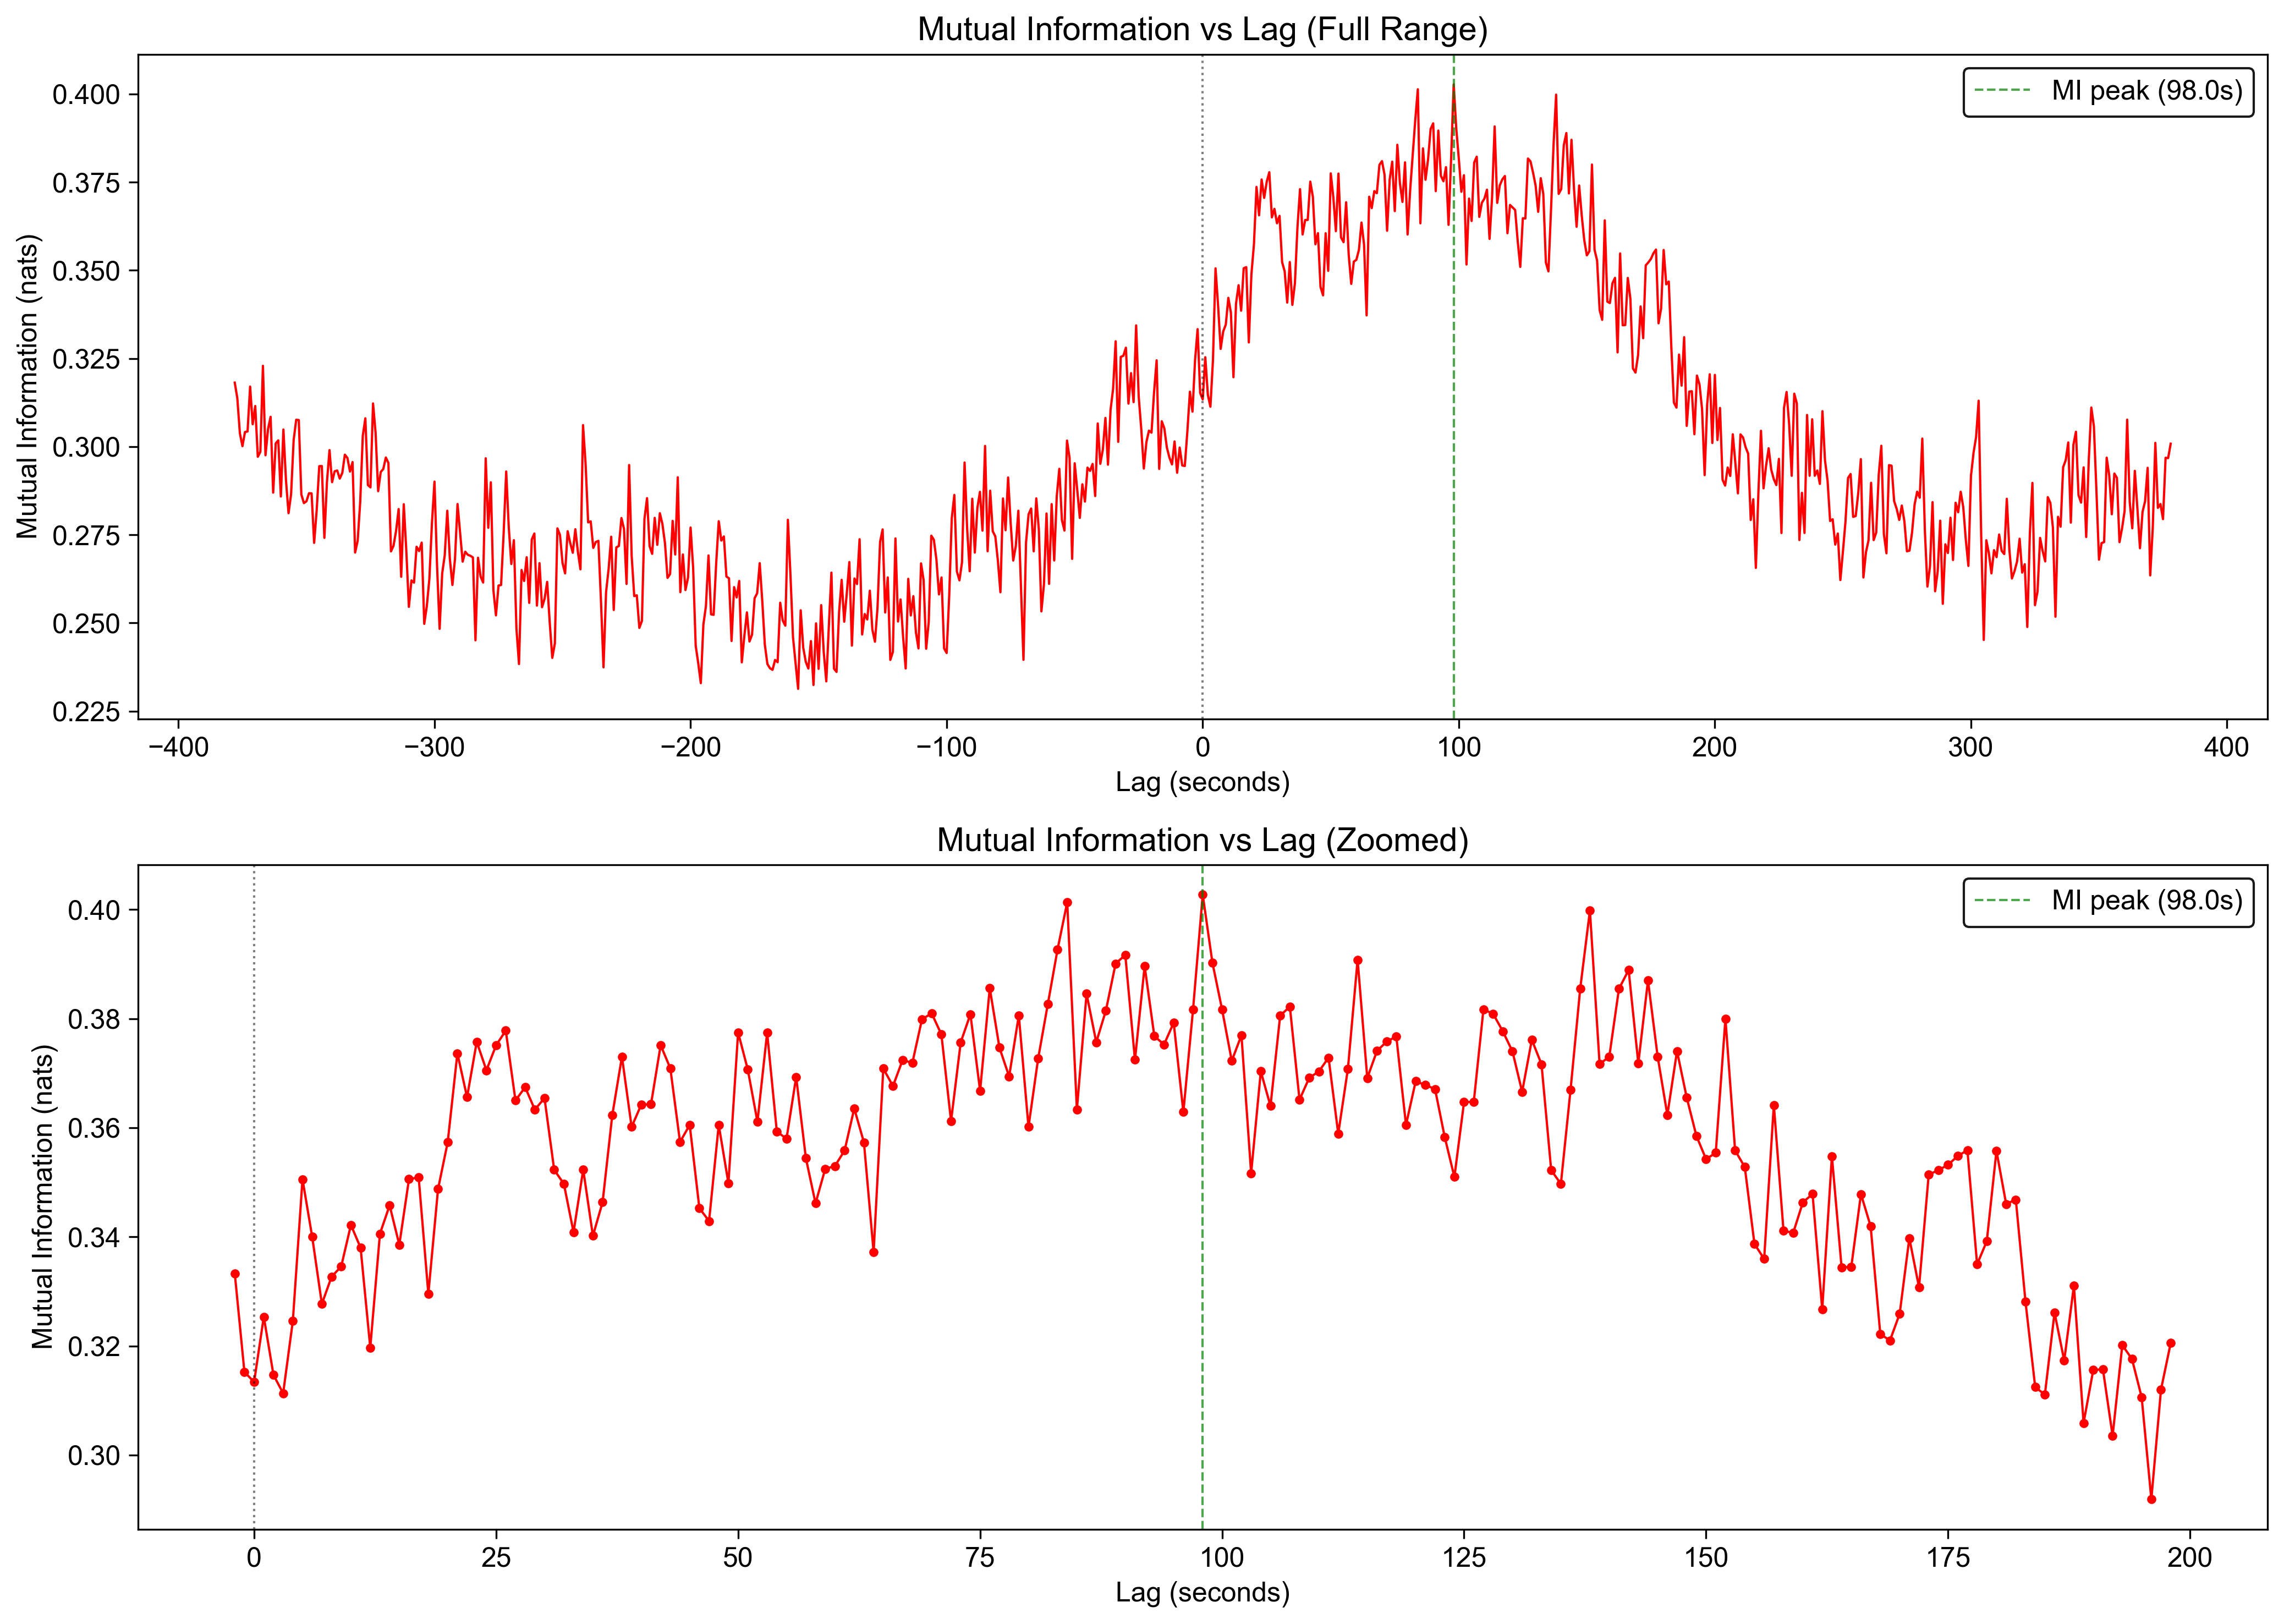

In [7]:
# Plot mutual information
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0].plot(mi_lags / sr, mi_values, 'r-', linewidth=1)
axes[0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0].axvline(x=mi_lag_sec, color='g', linestyle='--', alpha=0.7, label=f'MI peak ({mi_lag_sec:.1f}s)')
axes[0].set_xlabel('Lag (seconds)')
axes[0].set_ylabel('Mutual Information (nats)')
axes[0].set_title('Mutual Information vs Lag (Full Range)')
axes[0].legend(frameon=True, framealpha=0.9, edgecolor='black')

zoom_range = 100
mask = (mi_lags >= mi_lag - zoom_range) & (mi_lags <= mi_lag + zoom_range)
axes[1].plot(mi_lags[mask] / sr, mi_values[mask], 'r-o', linewidth=1, markersize=3)
axes[1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1].axvline(x=mi_lag_sec, color='g', linestyle='--', alpha=0.7, label=f'MI peak ({mi_lag_sec:.1f}s)')
axes[1].set_xlabel('Lag (seconds)')
axes[1].set_ylabel('Mutual Information (nats)')
axes[1].set_title('Mutual Information vs Lag (Zoomed)')
axes[1].legend(frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

## 3. Physical Transit Time (Real Lag)

In [10]:
# --- REAL LAG CALCULATION ---

# Load velocity data for physical transit time
df = pd.read_parquet('../data/datos_ind.pqt')
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')

# Use same time window as analysis 
index_start="2021-11-03 23:00:00"
index_end="2021-11-03 23:25:00"


df_hour = df.loc[index_start:index_end].copy()

vel = df_hour['Velocidad'].mean()

# Physical transit distance (belt/conveyor)
distance = 18600  # units
real_lag = int(distance / vel)
real_lag_sec = real_lag / sr

print(f'Average velocity: {vel:.2f} units/s')
print(f'Real lag (|distance/speed|): {real_lag}s ({real_lag/60:.1f} min)')

Average velocity: 225.00 units/s
Real lag (|distance/speed|): 82s (1.4 min)


## 4. Comparison of Methods

In [11]:
# --- COMPARISON ---

print(f"{'Method':<25} {'Lag (steps)':<15} {'Lag (seconds)':<15} {'Lag (minutes)'}")
print(f"{'-'*70}")
print(f"{'Cross-Correlation':<25} {cc_lag:<15} {cc_lag_sec:<15.1f} {cc_lag_sec/60:.2f}")
print(f"{'Mutual Information':<25} {mi_lag:<15} {mi_lag_sec:<15.1f} {mi_lag_sec/60:.2f}")
print(f"{'Real (Physical) Lag':<25} {real_lag:<15} {real_lag_sec:<15.1f} {real_lag_sec/60:.2f}")

print(f"\nErrors (steps):")
print(f"  Cross-Correlation: {abs(cc_lag - real_lag)} steps ({abs(cc_lag_sec - real_lag_sec):.1f}s)")
print(f"  Mutual Information: {abs(mi_lag - real_lag)} steps ({abs(mi_lag_sec - real_lag_sec):.1f}s)")

Method                    Lag (steps)     Lag (seconds)   Lag (minutes)
----------------------------------------------------------------------
Cross-Correlation         83              83.0            1.38
Mutual Information        98              98.0            1.63
Real (Physical) Lag       82              82.0            1.37

Errors (steps):
  Cross-Correlation: 1 steps (1.0s)
  Mutual Information: 16 steps (16.0s)
